In [1]:
import tensorflow as tf
import xarray as xr
import numpy as np
import pandas as pd
import os

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: []


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
base_dir = "../data"

netcdf_path = os.path.join(
    base_dir, "west_bengal_climate_final.nc"
)

stats_path = os.path.join(
    base_dir, "normalization_stats.csv"
)

ds = xr.open_dataset(netcdf_path)
stats_df = pd.read_csv(stats_path)

print(stats_df)

   variable       mean        std
0  rainfall   4.645871  13.518388
1      tmax  30.690184   4.541145
2      tmin  20.315073   5.800562


In [3]:
variables = ["rainfall", "tmax", "tmin"]

train_mean = stats_df.set_index("variable")["mean"].to_dict()
train_std = stats_df.set_index("variable")["std"].to_dict()

ds_norm = ds.copy()

for var in variables:
    ds_norm[var] = (
        (ds[var] - train_mean[var]) / train_std[var]
    )

print(ds_norm[variables])

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 4018, latitude: 7, longitude: 5)
Coordinates:
  * time       (time) datetime64[ns] 32kB 2015-01-01 2015-01-02 ... 2025-12-31
  * latitude   (latitude) float64 56B 21.5 22.5 23.5 24.5 25.5 26.5 27.5
  * longitude  (longitude) float64 40B 85.5 86.5 87.5 88.5 89.5
Data variables:
    rainfall   (time, latitude, longitude) float64 1MB nan nan ... -0.3437 nan
    tmax       (time, latitude, longitude) float32 563kB nan nan ... -2.588 nan
    tmin       (time, latitude, longitude) float32 563kB nan nan ... -1.919 nan
Attributes:
    title:                      VARUNA Climate Dataset
    description:                Daily IMD rainfall, maximum temperature, and ...
    region:                     West Bengal
    rainfall_source:            IMD 0.25 degree gridded rainfall
    temperature_source:         IMD 1 degree gridded temperature
    processing:                 Rainfall interpolated from 0.25 degree to 1 d...
    geographic_mask:           

In [4]:
# Keep the original chronological order
dates = pd.to_datetime(ds_norm.time.values)

# Shape: (time, latitude, longitude, channels)
data = np.stack(
    [ds_norm[var].values for var in variables],
    axis=-1
).astype(np.float32)

# Shape: (latitude, longitude)
mask = ds_norm["west_bengal_mask"].values.astype(bool)

print("Data shape:", data.shape)
print("Mask shape:", mask.shape)
print("Valid geographic cells:", mask.sum())
print("First date:", dates[0])
print("Last date:", dates[-1])

Data shape: (4018, 7, 5, 3)
Mask shape: (7, 5)
Valid geographic cells: 14
First date: 2015-01-01 00:00:00
Last date: 2025-12-31 00:00:00


In [6]:
valid_data = data[:, mask, :]

print("Valid-cell data shape:", valid_data.shape)
print("NaNs in valid cells:", np.isnan(valid_data).sum())
print("Infinite values:", np.isinf(valid_data).sum())

assert not np.isnan(valid_data).any(), (
    "Missing values found inside valid cells."
)

assert not np.isinf(valid_data).any(), (
    "Infinite values found in the dataset."
)

print("PASS: Valid cells contain no missing or infinite values.")

Valid-cell data shape: (4018, 14, 3)
NaNs in valid cells: 0
Infinite values: 0
PASS: Valid cells contain no missing or infinite values.


In [7]:
# Split boundaries are exclusive end indices
train_end = 2922
val_end = 2922 + 731
test_end = 4018

split_ranges = {
    "train": (7, train_end),
    "validation": (train_end, val_end),
    "test": (val_end, test_end)
}

for name, (start, end) in split_ranges.items():
    print(
        name,
        "| target period:",
        dates[start],
        "to",
        dates[end - 1]
    )

train | target period: 2015-01-08 00:00:00 to 2022-12-31 00:00:00
validation | target period: 2023-01-01 00:00:00 to 2024-12-31 00:00:00
test | target period: 2025-01-01 00:00:00 to 2025-12-31 00:00:00


In [8]:
def create_sequences(data, dates, mask, horizon, start_idx, end_idx):
    """
    data:      (time, latitude, longitude, channels)
    horizon:   number of future days to predict
    start_idx: first allowed target index
    end_idx:   exclusive end of allowed target period
    """

    X_conv_list = []
    y_list = []
    target_dates = []

    # t is the first day being predicted
    for t in range(start_idx, end_idx - horizon + 1):

        # Seven observations immediately before target day t
        x = data[t-7:t]

        # Future target days: t through t+horizon-1
        y = data[t:t+horizon]

        # Replace masked-out spatial cells with zero.
        # The geographic mask will exclude these cells from the loss.
        x = np.where(np.isfinite(x), x, 0.0)
        y = np.where(np.isfinite(y), y, 0.0)

        X_conv_list.append(x)
        y_list.append(y)
        target_dates.append(dates[t])

    X_conv = np.asarray(X_conv_list, dtype=np.float32)
    y = np.asarray(y_list, dtype=np.float32)

    # Normal LSTM: flatten each 7×5×3 daily grid into 105 features.
    X_lstm = X_conv.reshape(X_conv.shape[0], 7, -1)

    return X_lstm, X_conv, y, np.asarray(target_dates)

In [9]:
processed_dir = os.path.join(base_dir, "sequences")
os.makedirs(processed_dir, exist_ok=True)

horizons = [1, 3, 7]

sequence_data = {}

for horizon in horizons:
    sequence_data[horizon] = {}

    print(f"\n{'='*45}")
    print(f"FORECAST HORIZON: {horizon} day(s)")
    print(f"{'='*45}")

    for split_name, (start_idx, end_idx) in split_ranges.items():

        X_lstm, X_conv, y, target_dates = create_sequences(
            data=data,
            dates=dates,
            mask=mask,
            horizon=horizon,
            start_idx=start_idx,
            end_idx=end_idx
        )

        sequence_data[horizon][split_name] = {
            "X_lstm": X_lstm,
            "X_conv": X_conv,
            "y": y,
            "target_dates": target_dates
        }

        print(
            f"{split_name:10s} | "
            f"LSTM input: {X_lstm.shape} | "
            f"ConvLSTM input: {X_conv.shape} | "
            f"Target: {y.shape}"
        )


FORECAST HORIZON: 1 day(s)
train      | LSTM input: (2915, 7, 105) | ConvLSTM input: (2915, 7, 7, 5, 3) | Target: (2915, 1, 7, 5, 3)
validation | LSTM input: (731, 7, 105) | ConvLSTM input: (731, 7, 7, 5, 3) | Target: (731, 1, 7, 5, 3)
test       | LSTM input: (365, 7, 105) | ConvLSTM input: (365, 7, 7, 5, 3) | Target: (365, 1, 7, 5, 3)

FORECAST HORIZON: 3 day(s)
train      | LSTM input: (2913, 7, 105) | ConvLSTM input: (2913, 7, 7, 5, 3) | Target: (2913, 3, 7, 5, 3)
validation | LSTM input: (729, 7, 105) | ConvLSTM input: (729, 7, 7, 5, 3) | Target: (729, 3, 7, 5, 3)
test       | LSTM input: (363, 7, 105) | ConvLSTM input: (363, 7, 7, 5, 3) | Target: (363, 3, 7, 5, 3)

FORECAST HORIZON: 7 day(s)
train      | LSTM input: (2909, 7, 105) | ConvLSTM input: (2909, 7, 7, 5, 3) | Target: (2909, 7, 7, 5, 3)
validation | LSTM input: (725, 7, 105) | ConvLSTM input: (725, 7, 7, 5, 3) | Target: (725, 7, 7, 5, 3)
test       | LSTM input: (359, 7, 105) | ConvLSTM input: (359, 7, 7, 5, 3) | Target

In [10]:
for horizon in horizons:
    print(f"\nHorizon: {horizon} day(s)")

    for split_name in ["train", "validation", "test"]:
        item = sequence_data[horizon][split_name]

        print(
            split_name,
            "| samples:", len(item["X_conv"]),
            "| first target:", item["target_dates"][0],
            "| last target:", item["target_dates"][-1]
        )

        assert item["X_lstm"].shape[1:] == (7, 105)
        assert item["X_conv"].shape[1:] == (7, 7, 5, 3)
        assert item["y"].shape[1:] == (horizon, 7, 5, 3)

print("\nPASS: All sequence shapes are correct.")


Horizon: 1 day(s)
train | samples: 2915 | first target: 2015-01-08 00:00:00 | last target: 2022-12-31 00:00:00
validation | samples: 731 | first target: 2023-01-01 00:00:00 | last target: 2024-12-31 00:00:00
test | samples: 365 | first target: 2025-01-01 00:00:00 | last target: 2025-12-31 00:00:00

Horizon: 3 day(s)
train | samples: 2913 | first target: 2015-01-08 00:00:00 | last target: 2022-12-29 00:00:00
validation | samples: 729 | first target: 2023-01-01 00:00:00 | last target: 2024-12-29 00:00:00
test | samples: 363 | first target: 2025-01-01 00:00:00 | last target: 2025-12-29 00:00:00

Horizon: 7 day(s)
train | samples: 2909 | first target: 2015-01-08 00:00:00 | last target: 2022-12-25 00:00:00
validation | samples: 725 | first target: 2023-01-01 00:00:00 | last target: 2024-12-25 00:00:00
test | samples: 359 | first target: 2025-01-01 00:00:00 | last target: 2025-12-25 00:00:00

PASS: All sequence shapes are correct.


In [11]:
print("Number of valid cells:", int(mask.sum()))
print("Number of excluded cells:", int(mask.size - mask.sum()))

for horizon in horizons:
    y = sequence_data[horizon]["train"]["y"]

    # Check that placeholder values outside the geographic mask are zero.
    excluded_values = y[:, :, ~mask, :]

    print(
        f"{horizon}-day forecast | "
        f"maximum absolute excluded target value:",
        np.max(np.abs(excluded_values))
    )

Number of valid cells: 14
Number of excluded cells: 21
1-day forecast | maximum absolute excluded target value: 0.0
3-day forecast | maximum absolute excluded target value: 0.0
7-day forecast | maximum absolute excluded target value: 0.0


In [12]:
for horizon in horizons:
    for split_name in ["train", "validation", "test"]:

        item = sequence_data[horizon][split_name]

        output_path = os.path.join(
            processed_dir,
            f"{split_name}_{horizon}day.npz"
        )

        np.savez_compressed(
            output_path,
            X_lstm=item["X_lstm"],
            X_conv=item["X_conv"],
            y=item["y"],
            target_dates=item["target_dates"],
            mask=mask,
            variables=np.array(variables)
        )

        print("Saved:", output_path)

Saved: ../data\sequences\train_1day.npz
Saved: ../data\sequences\validation_1day.npz
Saved: ../data\sequences\test_1day.npz
Saved: ../data\sequences\train_3day.npz
Saved: ../data\sequences\validation_3day.npz
Saved: ../data\sequences\test_3day.npz
Saved: ../data\sequences\train_7day.npz
Saved: ../data\sequences\validation_7day.npz
Saved: ../data\sequences\test_7day.npz


In [13]:
check_path = os.path.join(processed_dir, "train_1day.npz")

with np.load(check_path) as saved:
    for key in saved.files:
        print(key, saved[key].shape)

X_lstm (2915, 7, 105)
X_conv (2915, 7, 7, 5, 3)
y (2915, 1, 7, 5, 3)


ValueError: Object arrays cannot be loaded when allow_pickle=False

In [14]:

import numpy as np
import os

check_path = os.path.join(processed_dir, "train_1day.npz")

with np.load(check_path, allow_pickle=False) as saved:
    print("Arrays stored in the file:", saved.files)

    for key in saved.files:
        try:
            arr = saved[key]
            print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")
        except ValueError as e:
            print(f"{key}: Could not load normally")
            print("Reason:", e)


Arrays stored in the file: ['X_lstm', 'X_conv', 'y', 'target_dates', 'mask', 'variables']
X_lstm: shape=(2915, 7, 105), dtype=float32
X_conv: shape=(2915, 7, 7, 5, 3), dtype=float32
y: shape=(2915, 1, 7, 5, 3), dtype=float32
target_dates: Could not load normally
Reason: Object arrays cannot be loaded when allow_pickle=False
mask: shape=(7, 5), dtype=bool
variables: shape=(3,), dtype=<U8


In [15]:

with np.load(check_path, allow_pickle=True) as saved:
    dates = saved["target_dates"]

    print("Shape:", dates.shape)
    print("Data type:", dates.dtype)
    print("First 5 dates:", dates[:5])
    print("Last 5 dates:", dates[-5:])


Shape: (2915,)
Data type: object
First 5 dates: [Timestamp('2015-01-08 00:00:00') Timestamp('2015-01-09 00:00:00')
 Timestamp('2015-01-10 00:00:00') Timestamp('2015-01-11 00:00:00')
 Timestamp('2015-01-12 00:00:00')]
Last 5 dates: [Timestamp('2022-12-27 00:00:00') Timestamp('2022-12-28 00:00:00')
 Timestamp('2022-12-29 00:00:00') Timestamp('2022-12-30 00:00:00')
 Timestamp('2022-12-31 00:00:00')]


In [16]:

target_dates = np.asarray(target_dates, dtype="datetime64[ns]")


In [17]:

np.savez_compressed(
    output_path,
    X_lstm=X_lstm.astype(np.float32),
    X_conv=X_conv.astype(np.float32),
    y=y.astype(np.float32),
    target_dates=np.asarray(target_dates, dtype="datetime64[ns]"),
    mask=mask.astype(bool),
    variables=np.asarray(variables, dtype=str)
)


In [18]:

with np.load(check_path, allow_pickle=False) as saved:
    for key in saved.files:
        arr = saved[key]
        print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")


X_lstm: shape=(2915, 7, 105), dtype=float32
X_conv: shape=(2915, 7, 7, 5, 3), dtype=float32
y: shape=(2915, 1, 7, 5, 3), dtype=float32


ValueError: Object arrays cannot be loaded when allow_pickle=False

In [19]:

import numpy as np
import os

check_path = os.path.join(processed_dir, "train_1day.npz")
fixed_path = os.path.join(processed_dir, "train_1day_fixed.npz")

# Only do this for your own trusted, locally generated file.
with np.load(check_path, allow_pickle=True) as saved:
    arrays = {key: saved[key] for key in saved.files}

# Convert dates from object dtype to native NumPy datetime
arrays["target_dates"] = np.asarray(
    arrays["target_dates"], dtype="datetime64[ns]"
)

# Save a corrected copy
np.savez_compressed(fixed_path, **arrays)

print("Corrected file saved:", fixed_path)
print("Target dates dtype:", arrays["target_dates"].dtype)
print("First 5 dates:", arrays["target_dates"][:5])


Corrected file saved: ../data\sequences\train_1day_fixed.npz
Target dates dtype: datetime64[ns]
First 5 dates: ['2015-01-08T00:00:00.000000000' '2015-01-09T00:00:00.000000000'
 '2015-01-10T00:00:00.000000000' '2015-01-11T00:00:00.000000000'
 '2015-01-12T00:00:00.000000000']


In [20]:

with np.load(fixed_path, allow_pickle=False) as saved:
    for key in saved.files:
        arr = saved[key]
        print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")


X_lstm: shape=(2915, 7, 105), dtype=float32
X_conv: shape=(2915, 7, 7, 5, 3), dtype=float32
y: shape=(2915, 1, 7, 5, 3), dtype=float32
target_dates: shape=(2915,), dtype=datetime64[ns]
mask: shape=(7, 5), dtype=bool
variables: shape=(3,), dtype=<U8


In [21]:

with np.load(fixed_path, allow_pickle=False) as saved:
    dates = saved["target_dates"]

    print("First target date:", dates[0])
    print("Last target date:", dates[-1])
    print("Number of samples:", len(dates))
    print("Dates are chronological:", np.all(dates[1:] > dates[:-1]))


First target date: 2015-01-08T00:00:00.000000000
Last target date: 2022-12-31T00:00:00.000000000
Number of samples: 2915
Dates are chronological: True


In [22]:

import os
import numpy as np

sequence_dir = os.path.join(
    "../data", "sequences"
)

for filename in [
    "train_1day_fixed.npz",
    "validation_1day.npz",
    "test_1day.npz"
]:
    path = os.path.join(sequence_dir, filename)
    print(filename, "exists:", os.path.exists(path))


train_1day_fixed.npz exists: True
validation_1day.npz exists: True
test_1day.npz exists: True


In [23]:

train_path = os.path.join(processed_dir, "train_1day_fixed.npz")
val_path = os.path.join(processed_dir, "validation_1day.npz")
test_path = os.path.join(processed_dir, "test_1day.npz")

def load_sequences(path):
    with np.load(path, allow_pickle=False) as data:
        return {key: data[key] for key in data.files}

train_data = load_sequences(train_path)
val_data = load_sequences(val_path)
test_data = load_sequences(test_path)

X_train = train_data["X_lstm"]
y_train = train_data["y"]

X_val = val_data["X_lstm"]
y_val = val_data["y"]

X_test = test_data["X_lstm"]
y_test = test_data["y"]

mask = train_data["mask"]

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)
print("Selected grid cells:", mask.sum())


ValueError: Object arrays cannot be loaded when allow_pickle=False

In [24]:

import os
import numpy as np

for filename in ["validation_1day.npz", "test_1day.npz"]:
    path = os.path.join(processed_dir, filename)

    print(f"\n--- {filename} ---")

    with np.load(path, allow_pickle=False) as saved:
        for key in saved.files:
            try:
                arr = saved[key]
                print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")
            except ValueError:
                print(f"{key}: OBJECT ARRAY — needs correction")



--- validation_1day.npz ---
X_lstm: shape=(731, 7, 105), dtype=float32
X_conv: shape=(731, 7, 7, 5, 3), dtype=float32
y: shape=(731, 1, 7, 5, 3), dtype=float32
target_dates: OBJECT ARRAY — needs correction
mask: shape=(7, 5), dtype=bool
variables: shape=(3,), dtype=<U8

--- test_1day.npz ---
X_lstm: shape=(365, 7, 105), dtype=float32
X_conv: shape=(365, 7, 7, 5, 3), dtype=float32
y: shape=(365, 1, 7, 5, 3), dtype=float32
target_dates: OBJECT ARRAY — needs correction
mask: shape=(7, 5), dtype=bool
variables: shape=(3,), dtype=<U8


In [25]:

def fix_date_array(source_path, output_path):
    with np.load(source_path, allow_pickle=True) as saved:
        arrays = {key: saved[key] for key in saved.files}

    if "target_dates" in arrays:
        arrays["target_dates"] = np.asarray(
            arrays["target_dates"],
            dtype="datetime64[ns]"
        )

    np.savez_compressed(output_path, **arrays)
    print("Corrected:", output_path)


val_path = os.path.join(processed_dir, "validation_1day.npz")
test_path = os.path.join(processed_dir, "test_1day.npz")

val_fixed_path = os.path.join(
    processed_dir, "validation_1day_fixed.npz"
)
test_fixed_path = os.path.join(
    processed_dir, "test_1day_fixed.npz"
)

fix_date_array(val_path, val_fixed_path)
fix_date_array(test_path, test_fixed_path)


Corrected: ../data\sequences\validation_1day_fixed.npz
Corrected: ../data\sequences\test_1day_fixed.npz


In [26]:

train_path = os.path.join(processed_dir, "train_1day_fixed.npz")

train_data = load_sequences(train_path)
val_data = load_sequences(val_fixed_path)
test_data = load_sequences(test_fixed_path)

X_train, y_train = train_data["X_lstm"], train_data["y"]
X_val, y_val = val_data["X_lstm"], val_data["y"]
X_test, y_test = test_data["X_lstm"], test_data["y"]

mask = train_data["mask"]

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)
print("Selected grid cells:", mask.sum())


Training: (2915, 7, 105) (2915, 1, 7, 5, 3)
Validation: (731, 7, 105) (731, 1, 7, 5, 3)
Testing: (365, 7, 105) (365, 1, 7, 5, 3)
Selected grid cells: 14


In [27]:

# Verify that all three splits use the same spatial mask
print("Training mask cells:", train_data["mask"].sum())
print("Validation mask cells:", val_data["mask"].sum())
print("Test mask cells:", test_data["mask"].sum())

assert np.array_equal(train_data["mask"], val_data["mask"])
assert np.array_equal(train_data["mask"], test_data["mask"])

print("All splits use the same spatial mask.")


Training mask cells: 14
Validation mask cells: 14
Test mask cells: 14
All splits use the same spatial mask.


In [28]:

# Flatten the 7 x 5 spatial mask into 35 indicators
mask_features = mask.astype(np.float32).reshape(1, 1, 35)

def add_mask_features(X):
    # X shape: (samples, 7 days, 105 features)
    mask_repeated = np.broadcast_to(
        mask_features,
        (X.shape[0], X.shape[1], 35)
    )
    return np.concatenate([X, mask_repeated], axis=-1).astype(
        np.float32
    )

X_train_lstm = add_mask_features(X_train)
X_val_lstm = add_mask_features(X_val)
X_test_lstm = add_mask_features(X_test)

print("Training input:", X_train_lstm.shape)
print("Validation input:", X_val_lstm.shape)
print("Test input:", X_test_lstm.shape)


Training input: (2915, 7, 140)
Validation input: (731, 7, 140)
Test input: (365, 7, 140)


In [29]:

import tensorflow as tf
from tensorflow.keras import layers, Model

tf.keras.utils.set_random_seed(42)

inputs = layers.Input(shape=(7, 140), name="climate_history")

x = layers.LSTM(64)(inputs)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(7 * 5 * 3)(x)

outputs = layers.Reshape((1, 7, 5, 3))(x)

lstm_model = Model(inputs, outputs, name="VARUNA_LSTM")
lstm_model.summary()


Model: "VARUNA_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ climate_history (InputLayer)    │ (None, 7, 140)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        52,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 105)            │        13,545 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 7, 5, 3)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,345 (290.41 KB)

 Trainable params: 74,345 (290.41 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:

print("Mask shape:", mask.shape)
print("Selected cells:", int(mask.sum()))
print("Target shape:", y_train.shape)

# Check whether target values are finite
print("All target values finite:", np.isfinite(y_train).all())

# Check that the mask is identical across splits
assert np.array_equal(train_data["mask"], val_data["mask"])
assert np.array_equal(train_data["mask"], test_data["mask"])

# Check target values in excluded cells
excluded = ~mask
excluded_values = y_train[:, :, excluded, :]

print("Excluded-cell target shape:", excluded_values.shape)
print("Excluded-cell values are all zero:",
      np.allclose(excluded_values, 0.0))


Mask shape: (7, 5)
Selected cells: 14
Target shape: (2915, 1, 7, 5, 3)
All target values finite: True
Excluded-cell target shape: (2915, 1, 21, 3)
Excluded-cell values are all zero: True


In [31]:

mask_tf = tf.constant(
    mask.astype(np.float32)[None, None, :, :, None]
)

def masked_mse(y_true, y_pred):
    squared_error = tf.square(y_true - y_pred) * mask_tf

    denominator = (
        tf.reduce_sum(mask_tf)
        * tf.cast(
            tf.shape(y_true)[0] * tf.shape(y_true)[1] * 3,
            tf.float32
        )
    )

    return tf.reduce_sum(squared_error) / denominator

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=masked_mse
)

print("LSTM compiled successfully.")


LSTM compiled successfully.


In [32]:

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    shuffle=True,
    verbose=1
)


Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.4630 - val_loss: 0.3155
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3266 - val_loss: 0.2805
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3031 - val_loss: 0.2646
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2908 - val_loss: 0.2561
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2819 - val_loss: 0.2513
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2750 - val_loss: 0.2456
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2692 - val_loss: 0.2441
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2639 - val_loss: 0.2409
Epoch 9/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2609 - val_loss: 0.2399
Epoch 10/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2572 - val_loss: 0.2398
Epoch 11/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2519 - val_loss: 0.2404
Epoch 12/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2493 - val_l

In [33]:

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_val_loss = float(np.min(history.history["val_loss"]))

print("Best epoch:", best_epoch)
print("Best validation loss:", round(best_val_loss, 4))
print("Epochs completed:", len(history.history["loss"]))


Best epoch: 12
Best validation loss: 0.2392
Epochs completed: 20


In [34]:

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "varuna_lstm_1day.keras")
history_path = os.path.join(model_dir, "varuna_lstm_1day_history.npz")

lstm_model.save(model_path)

np.savez_compressed(
    history_path,
    loss=np.asarray(history.history["loss"]),
    val_loss=np.asarray(history.history["val_loss"])
)

print("Model saved:", model_path)
print("History saved:", history_path)


Model saved: ../models\varuna_lstm_1day.keras
History saved: ../models\varuna_lstm_1day_history.npz


In [35]:

import os
import numpy as np
import tensorflow as tf

model_path = "../models/varuna_lstm_1day.keras"

# Load the trained model without recompiling its custom loss
loaded_lstm = tf.keras.models.load_model(
    model_path,
    compile=False
)

# Predict the 2025 test period
y_pred_norm = loaded_lstm.predict(
    X_test_lstm,
    batch_size=32,
    verbose=1
)

print("Prediction shape:", y_pred_norm.shape)
print("Actual target shape:", y_test.shape)
print("Predictions are finite:", np.isfinite(y_pred_norm).all())


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
Prediction shape: (365, 1, 7, 5, 3)
Actual target shape: (365, 1, 7, 5, 3)
Predictions are finite: True


In [36]:

# Variable order: rainfall, tmax, tmin
means = np.array([4.645871, 30.690012, 20.315042],
                 dtype=np.float32)

stds = np.array([13.518388, 4.541152, 5.800548],
                dtype=np.float32)

# Reverse z-score normalization
y_pred = y_pred_norm * stds.reshape(1, 1, 1, 1, 3) \
          + means.reshape(1, 1, 1, 1, 3)

y_actual = y_test * stds.reshape(1, 1, 1, 1, 3) \
            + means.reshape(1, 1, 1, 1, 3)

print("Predictions converted to original units.")
print("Prediction shape:", y_pred.shape)


Predictions converted to original units.
Prediction shape: (365, 1, 7, 5, 3)


In [37]:

from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd

variable_names = ["Rainfall", "Tmax", "Tmin"]
units = ["mm/day", "°C", "°C"]

# Remove the singleton forecast-horizon dimension
pred_valid = y_pred[:, 0][:, mask, :]       # (365, 14, 3)
actual_valid = y_actual[:, 0][:, mask, :]   # (365, 14, 3)

results = []

for i, variable in enumerate(variable_names):
    actual_values = actual_valid[:, :, i].ravel()
    predicted_values = pred_valid[:, :, i].ravel()

    mae = mean_absolute_error(actual_values, predicted_values)
    rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))

    results.append({
        "Variable": variable,
        "Unit": units[i],
        "MAE": mae,
        "RMSE": rmse
    })

metrics_df = pd.DataFrame(results)
print(metrics_df.round(4).to_string(index=False))


Variable   Unit    MAE    RMSE
Rainfall mm/day 5.2703 10.8775
    Tmax     °C 1.0203  1.3412
    Tmin     °C 0.7435  0.9670


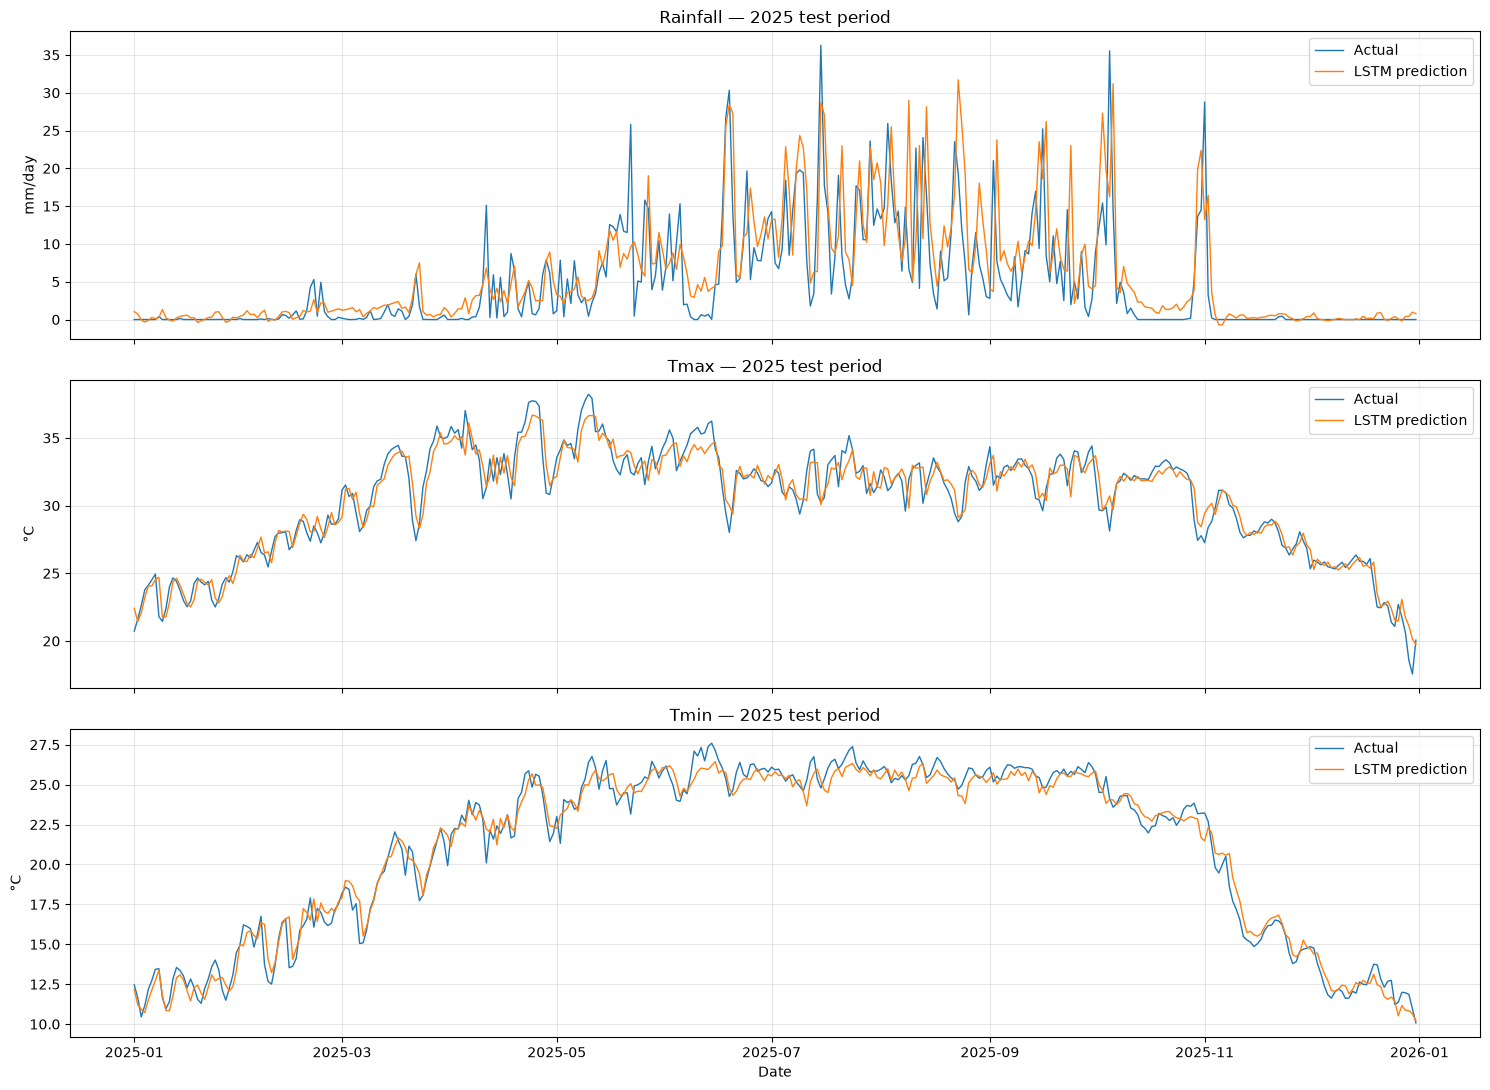

In [38]:

import matplotlib.pyplot as plt

test_dates = pd.to_datetime(test_data["target_dates"])

# Average across the 14 selected cells for each test day
actual_daily_mean = actual_valid.mean(axis=1)
pred_daily_mean = pred_valid.mean(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

for i, (variable, unit) in enumerate(zip(variable_names, units)):
    axes[i].plot(
        test_dates, actual_daily_mean[:, i],
        label="Actual", linewidth=1
    )
    axes[i].plot(
        test_dates, pred_daily_mean[:, i],
        label="LSTM prediction", linewidth=1
    )
    axes[i].set_title(f"{variable} — 2025 test period")
    axes[i].set_ylabel(unit)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()
